In [51]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [75]:
l = serial.Serial()
l.port="/dev/ttyUSB01"
l.baudrate = 115200
l.bytesize = 8
l.open()
l.close()



SerialException: [Errno 2] could not open port /dev/ttyUSB01: [Errno 2] No such file or directory: '/dev/ttyUSB01'

In [53]:
import random as rd
import time

In [54]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [55]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*10**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*10**(BitsPorSimbolo))
  return [Ain,Bin]

In [56]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [57]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [58]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [78]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")


  s = serial.Serial()
  s.port = "/dev/ttyUSB7"
  s.baudrate = 115200
  s.bytesize = 8
  s.open()
  Fs =1000
  cmp = len(str(X[0][0]))
  #file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray(X[j][i]))
    #print('0b'+strbin,i)
    #print(int('0b'+strbin,2))
    #file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
      time.sleep(1/Fs)  
  s.write(bytearray([0]))
  s.write(bytearray([0]))
  s.write(bytearray([0]))
  s.close()  
  #file.close()
 

In [60]:
M = create_matrix(Din = 16, BitsPorSimbolo=np.log2(1))
#print_matrix(M[1])


In [79]:
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",1)
    send_matrix(M_p[1],"IMPUT_B",1)
    
    break
    time.sleep(10)

---------------------- 0 --------------------------


SerialException: [Errno 2] could not open port /dev/ttyUSB7: [Errno 2] No such file or directory: '/dev/ttyUSB7'

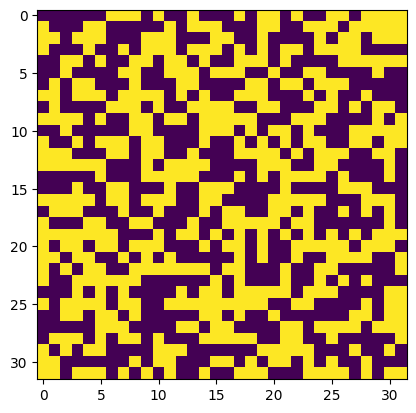

In [ ]:
plt.imshow(M[1])

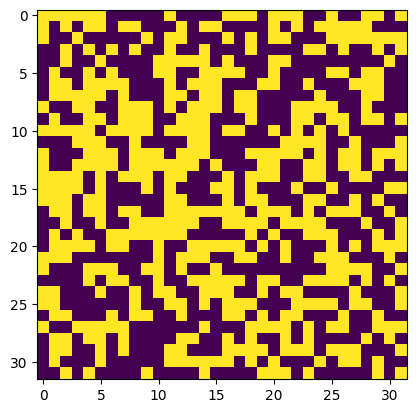

In [ ]:
plt.imshow(M[0])

In [ ]:
M[0]@M[1]

array([[12,  6,  9, ...,  7, 12, 10],
       [ 6,  5,  8, ...,  8, 11,  9],
       [12,  7,  8, ...,  6, 11,  9],
       ...,
       [13,  8,  8, ...,  7, 12, 10],
       [ 8,  3,  7, ...,  6, 12,  5],
       [ 8,  5,  5, ...,  5,  7,  6]], shape=(32, 32))

M_p = shiftMatrixSystolic(M[0],M[1])

In [ ]:
M[1]@M[0]

array([[ 5, 11,  9, ...,  8,  3,  7],
       [ 7, 11,  8, ...,  8,  6, 11],
       [ 7, 11, 10, ..., 10,  3, 10],
       ...,
       [ 7,  7,  5, ...,  8,  7,  8],
       [ 8,  8,  9, ...,  3,  5,  6],
       [ 5, 12, 11, ...,  9,  4,  9]], shape=(32, 32))

---------------------- 0 --------------------------


SerialException: [Errno 5] could not open port /dev/ttyUSB1: [Errno 5] Input/output error: '/dev/ttyUSB1'

In [ ]:
M[0]@M[1]

array([[12,  6,  9, ...,  7, 12, 10],
       [ 6,  5,  8, ...,  8, 11,  9],
       [12,  7,  8, ...,  6, 11,  9],
       ...,
       [13,  8,  8, ...,  7, 12, 10],
       [ 8,  3,  7, ...,  6, 12,  5],
       [ 8,  5,  5, ...,  5,  7,  6]], shape=(32, 32))

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, ..., 1, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0]], shape=(32, 63)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 1, ..., 0, 0, 0]], shape=(32, 63)))

In [ ]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [ ]:
M[0]@M[1]

array([[12,  6,  9, ...,  7, 12, 10],
       [ 6,  5,  8, ...,  8, 11,  9],
       [12,  7,  8, ...,  6, 11,  9],
       ...,
       [13,  8,  8, ...,  7, 12, 10],
       [ 8,  3,  7, ...,  6, 12,  5],
       [ 8,  5,  5, ...,  5,  7,  6]], shape=(32, 32))

In [ ]:
M

[array([[1, 1, 1, ..., 1, 0, 1],
        [1, 0, 1, ..., 0, 0, 0],
        [1, 0, 0, ..., 1, 1, 1],
        ...,
        [0, 1, 1, ..., 0, 0, 1],
        [0, 1, 0, ..., 1, 0, 0],
        [0, 0, 1, ..., 1, 0, 1]], shape=(32, 32)),
 array([[0, 0, 0, ..., 1, 1, 1],
        [1, 0, 0, ..., 1, 1, 1],
        [1, 1, 0, ..., 1, 1, 1],
        ...,
        [1, 0, 1, ..., 0, 1, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 1, 1]], shape=(32, 32))]

In [ ]:
M_p[0]

array([[0, 0, 0, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], shape=(32, 63))

In [ ]:
M_p[1]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0]], shape=(32, 63))

In [ ]:
def send_matrix(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [ ]:
len(str("0000000000000009"))*4


64

In [ ]:
M[0]@M[1]

array([[12,  6,  9, ...,  7, 12, 10],
       [ 6,  5,  8, ...,  8, 11,  9],
       [12,  7,  8, ...,  6, 11,  9],
       ...,
       [13,  8,  8, ...,  7, 12, 10],
       [ 8,  3,  7, ...,  6, 12,  5],
       [ 8,  5,  5, ...,  5,  7,  6]], shape=(32, 32))

In [ ]:
M_p[1]

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], shape=(32, 63))

In [ ]:
print_matrix(M[0]@M[1])

12 6 9 10 10 11 4 10 8 10 10 11 5 7 11 7 8 13 5 12 7 8 9 10 9 8 8 7 10 7 12 10 
6 5 8 9 4 11 7 10 10 7 9 7 8 8 10 9 9 12 6 10 6 7 7 6 9 9 8 6 7 8 11 9 
12 7 8 9 7 10 7 10 8 9 9 8 4 6 9 8 7 12 7 10 7 7 12 9 8 9 7 6 9 6 11 9 
6 4 3 8 6 10 4 5 6 6 5 5 5 4 6 5 3 8 5 10 5 7 4 6 8 4 6 6 5 3 10 6 
8 6 6 6 4 5 4 5 4 9 7 7 3 4 5 5 5 6 3 7 6 6 5 7 8 5 5 4 6 6 8 4 
6 4 9 10 5 9 5 6 7 6 7 7 5 4 11 7 6 8 5 8 6 10 7 9 6 4 6 7 10 5 11 7 
9 6 7 11 8 13 6 7 7 7 8 8 9 7 8 8 6 9 4 11 4 11 6 8 10 8 8 8 7 7 10 7 
8 5 6 8 6 10 3 9 5 8 9 8 6 6 9 7 6 11 6 11 7 9 6 9 8 6 7 7 6 5 10 6 
9 6 7 11 7 12 5 11 10 9 9 8 8 8 13 8 8 14 7 11 6 11 7 8 9 8 7 5 8 4 10 8 
11 7 10 9 9 14 4 8 11 9 7 10 9 9 11 8 7 13 8 11 8 7 7 9 10 8 5 5 7 6 11 8 
11 9 9 12 8 12 7 9 9 12 12 9 8 9 14 8 6 13 6 14 9 10 8 9 14 11 9 7 9 9 14 9 
6 4 4 6 6 8 3 8 5 7 4 8 7 7 7 6 4 9 3 8 4 8 4 4 10 8 7 5 4 4 7 6 
11 9 11 10 8 13 7 8 12 11 9 10 11 11 10 9 9 14 9 14 11 11 10 11 12 13 9 8 8 10 15 11 
10 7 10 12 7 12 10 11 10 9 8 8 9 9 12 11 7 13 7 13 9 12

In [ ]:
M[0]@M[1]

array([[12,  6,  9, ...,  7, 12, 10],
       [ 6,  5,  8, ...,  8, 11,  9],
       [12,  7,  8, ...,  6, 11,  9],
       ...,
       [13,  8,  8, ...,  7, 12, 10],
       [ 8,  3,  7, ...,  6, 12,  5],
       [ 8,  5,  5, ...,  5,  7,  6]], shape=(32, 32))

In [ ]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, ..., 1, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0]], shape=(32, 63)),
 array([[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(32, 63))]

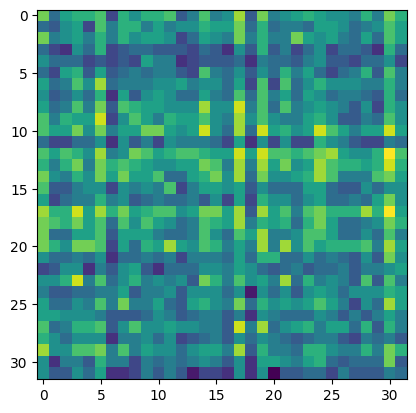

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

In [ ]:

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"../INPUT_A",0)
    send_matrix(M_p[1],"../INUPT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


FileNotFoundError: [Errno 2] No such file or directory: '../teste../INPUT_A.mem'

In [ ]:
M[0]

array([[0, 1, 1, ..., 0, 1, 1],
       [0, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [1, 1, 0, ..., 0, 0, 1],
       [1, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0]], shape=(32, 32))

In [ ]:
M[1]

array([[0, 0, 0, ..., 0, 0, 1],
       [1, 1, 1, ..., 0, 0, 1],
       [0, 1, 1, ..., 1, 1, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 1],
       [1, 0, 1, ..., 0, 1, 0],
       [1, 1, 1, ..., 1, 0, 1]], shape=(32, 32))

In [ ]:
M[0]@M[1]

array([[11, 12, 12, ...,  7, 12,  7],
       [ 9, 12, 11, ...,  8,  9,  8],
       [ 6,  9,  5, ...,  5,  7,  6],
       ...,
       [ 7,  7,  6, ...,  4,  6,  8],
       [ 4,  6,  4, ...,  4,  7,  7],
       [ 5,  5,  5, ...,  3,  7,  5]], shape=(32, 32))

In [ ]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

SerialException: [Errno 5] could not open port /dev/ttyUSB1: [Errno 5] Input/output error: '/dev/ttyUSB1'

In [ ]:
i =1
s.write(bytearray([int(i)]))


1

In [ ]:
serial.Serial()

Serial<id=0x7f8d3cb31060, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)